In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.core.magic_arguments import magic_arguments
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

data= pd.read_csv('cleaned_online_retail',
                  parse_dates=["InvoiceDate"],
                  dtype={
                    "InvoiceNo": str,
                    "StockCode": str,
                    "Description": str,
                    "CustomerID": str,
                    "Country": str}
                  )
data["Quantity"] = data["Quantity"].astype(int)
data["UnitPrice"] = data["UnitPrice"].astype(float)
data["TotalAmount"] = data["TotalAmount"].astype(float)

print(data.shape)


(392692, 9)


In [35]:
snapshot_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = data.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
}).reset_index()
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]
print(rfm.head())
print(rfm.describe())


  CustomerID  Recency  Frequency  Monetary
0    12346.0      326          1  77183.60
1    12347.0        2          7   4310.00
2    12348.0       75          4   1797.24
3    12349.0       19          1   1757.55
4    12350.0      310          1    334.40
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


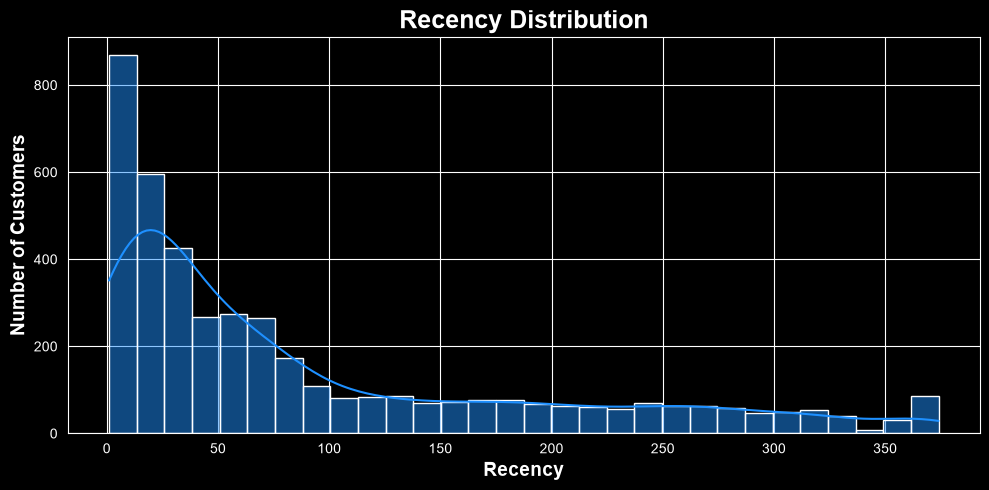

In [36]:
plt.figure(figsize=(10, 5))
sns.histplot(rfm["Recency"],bins=30,kde=True,color = "dodgerblue")
plt.title("Recency Distribution",fontsize=18,fontweight='bold')
plt.xlabel("Recency",fontsize=14,fontweight='bold')
plt.ylabel("Number of Customers",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


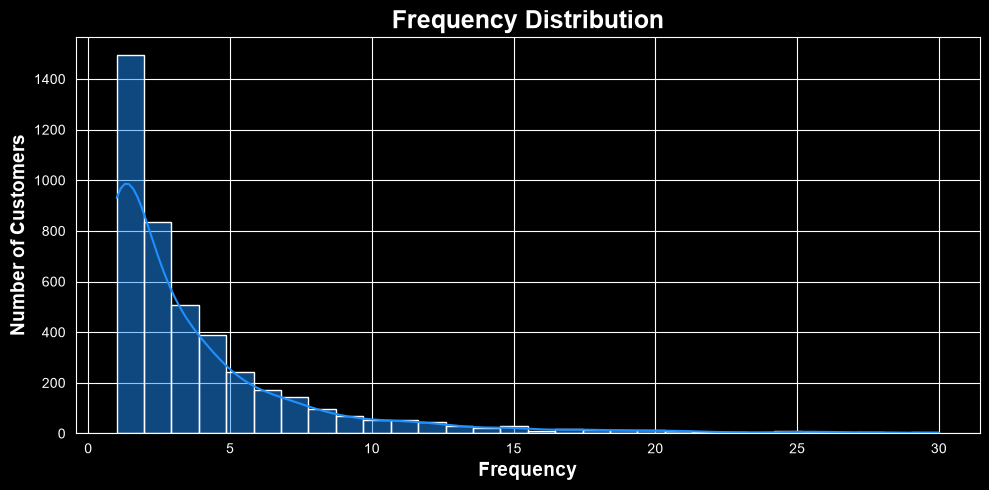

In [37]:
freq_plot = rfm[rfm["Frequency"] <= rfm["Frequency"].quantile(0.99)]
plt.figure(figsize=(10, 5))
sns.histplot(
    data = freq_plot,
    x="Frequency",
    bins=30,
    kde=True,
    color = "dodgerblue"
)
plt.title("Frequency Distribution",fontsize=18,fontweight='bold')
plt.xlabel("Frequency",fontsize=14,fontweight='bold')
plt.ylabel("Number of Customers",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

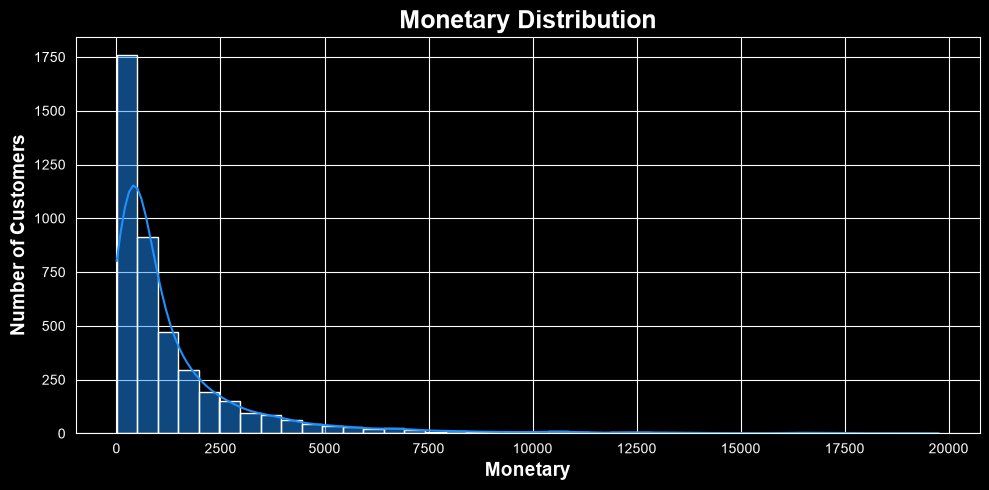

In [38]:
monetary_plot = rfm[rfm["Monetary"] <= rfm["Monetary"].quantile(0.99)]
plt.figure(figsize=(10, 5))
sns.histplot(
    data = monetary_plot,
    x="Monetary",
    bins=40,
    kde = True,
    color = "dodgerblue",
)
plt.title("Monetary Distribution",fontsize=18,fontweight='bold')
plt.xlabel("Monetary",fontsize=14,fontweight='bold')
plt.ylabel("Number of Customers",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# Log-Transform to handle Skewness before Clustering

rfm_log = rfm.copy()
rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])


In [40]:
# Scale the Features

features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[features])


In [57]:
# Find the best Number of Cluster
# Use both Elbow Method and Silhouette Score

inertia = []
silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, cluster_labels))


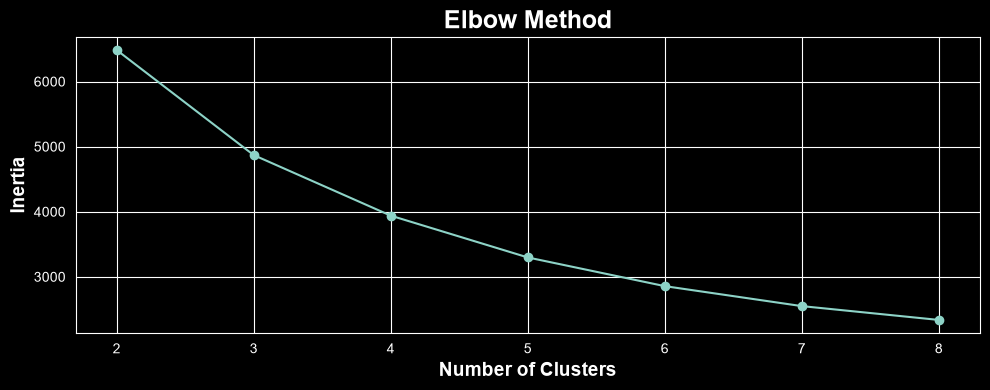

In [58]:
# Plot Elbow Curve

plt.figure(figsize=(10, 4))
plt.plot(list(k_values), inertia, marker="o")
plt.title("Elbow Method",fontsize=18,fontweight='bold')
plt.xlabel("Number of Clusters",fontsize=14,fontweight='bold')
plt.ylabel("Inertia",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


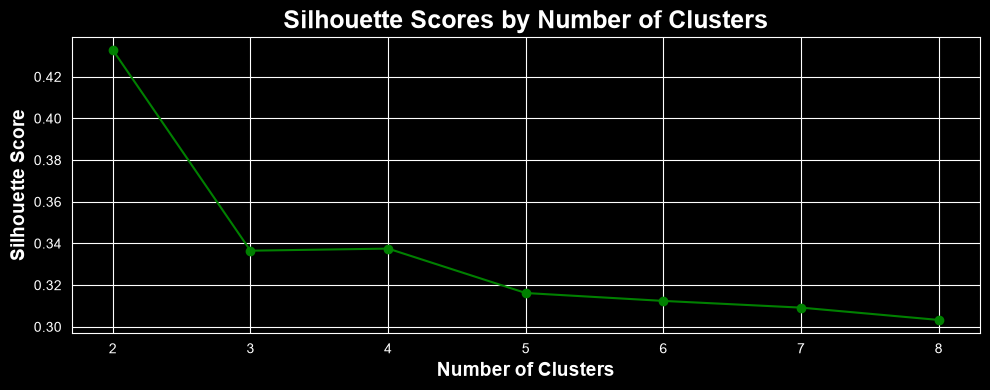

Best k based on silhouette: 2


In [59]:
# Silhouette Score

plt.figure(figsize=(10, 4))
plt.plot(list(k_values), silhouette_scores, marker="o", color="green")
plt.title("Silhouette Scores by Number of Clusters",fontsize=18,fontweight='bold')
plt.xlabel("Number of Clusters",fontsize=14,fontweight='bold')
plt.ylabel("Silhouette Score",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

best_k = list(k_values)[np.argmax(silhouette_scores)]
print("Best k based on silhouette:", best_k)


In [122]:
# Train Final Clustering Model
final_k = 4

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm.head(5))

  CustomerID  Recency  Frequency  Monetary  Cluster     Segment
0    12346.0      326          1  77183.60        3     At-Risk
1    12347.0        2          7   4310.00        0  High-Value
2    12348.0       75          4   1797.24        3     At-Risk
3    12349.0       19          1   1757.55        2  Occasional
4    12350.0      310          1    334.40        1     Regular


In [112]:
BEST_K = 4  # adjust after inspecting elbow_silhouette plot
kmeans_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
rfm["Cluster"] = kmeans_final.fit_predict(rfm_scaled)

print("Final Silhouette Score:", silhouette_score(rfm_scaled, rfm["Cluster"]))

# Cluster profile (mean RFM per cluster)
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
print(cluster_profile)

Final Silhouette Score: 0.33751704921261194
         Recency  Frequency  Monetary
Cluster                              
0          12.17      13.75   8088.02
1         181.51       1.32    341.00
2          17.70       2.19    557.32
3          71.64       4.08   1801.78


In [113]:
cluster_size = rfm["Cluster"].value_counts().sort_index()
print(cluster_size)

Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


In [115]:
# Assigning labels after seeing actual cluster averages
cluster_name_map = {
    0: "High-Value",
    1: "Regular",
    2: "Occasional",
    3: "At-Risk"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_name_map)
print(rfm.head(5))


  CustomerID  Recency  Frequency  Monetary  Cluster     Segment
0    12346.0      326          1  77183.60        3     At-Risk
1    12347.0        2          7   4310.00        0  High-Value
2    12348.0       75          4   1797.24        3     At-Risk
3    12349.0       19          1   1757.55        2  Occasional
4    12350.0      310          1    334.40        1     Regular


In [116]:
# Save Cluster Profile

profile_df = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(2)
profile_df.to_csv("cluster_profiles.csv")


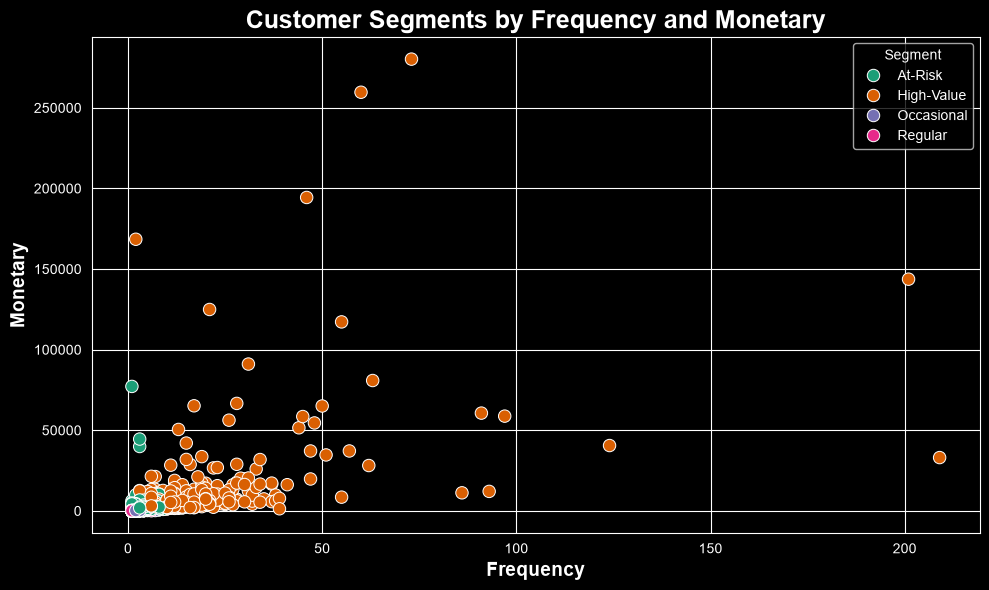

In [79]:
# Visualizing Cluster
# 2D Scatter Plot

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette="Dark2",
    s=80
)
plt.title("Customer Segments by Frequency and Monetary",fontsize=18,fontweight='bold')
plt.xlabel("Frequency",fontsize=14,fontweight='bold')
plt.ylabel("Monetary",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()



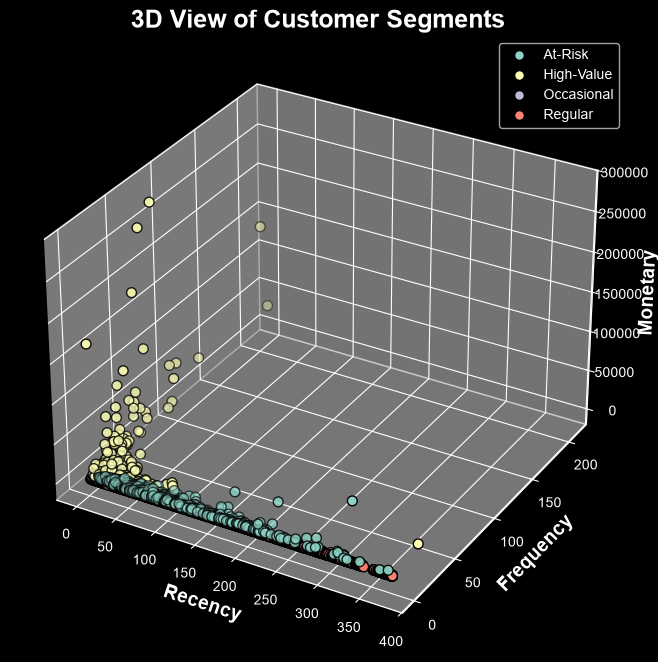

In [120]:
# 3D Plot

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

for seg in rfm["Segment"].unique():
    subset = rfm[rfm["Segment"] == seg]
    ax.scatter(
        subset["Recency"],
        subset["Frequency"],
        subset["Monetary"],
        edgecolors="black",
        s=50,
        label=seg
    )
ax.set_xlabel("Recency",fontsize=14,fontweight='bold')
ax.set_ylabel("Frequency",fontsize=14,fontweight='bold')
ax.set_zlabel("Monetary",fontsize=14,fontweight='bold')
ax.set_title("3D View of Customer Segments",fontsize=18,fontweight='bold')
ax.legend()
plt.show()

In [124]:
# Creating Customer-Product Matrix

customer_product_matrix = data.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

print(customer_product_matrix.shape)

(4338, 3866)


In [84]:
# Computing Item-Item Similarity

product_matrix = customer_product_matrix.T
product_similarity = cosine_similarity(product_matrix)
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=product_matrix.index,
    columns=product_matrix.index
)
print(product_similarity_df.iloc[:5, :5])


Description                   10 COLOUR SPACEBOY PEN  \
Description                                            
10 COLOUR SPACEBOY PEN                      1.000000   
12 COLOURED PARTY BALLOONS                  0.030829   
12 DAISY PEGS IN WOOD BOX                   0.005989   
12 EGG HOUSE PAINTED WOOD                   0.001467   
12 HANGING EGGS HAND PAINTED                0.000000   

Description                   12 COLOURED PARTY BALLOONS  \
Description                                                
10 COLOUR SPACEBOY PEN                          0.030829   
12 COLOURED PARTY BALLOONS                      1.000000   
12 DAISY PEGS IN WOOD BOX                       0.049282   
12 EGG HOUSE PAINTED WOOD                       0.057428   
12 HANGING EGGS HAND PAINTED                    0.007737   

Description                   12 DAISY PEGS IN WOOD BOX  \
Description                                               
10 COLOUR SPACEBOY PEN                         0.005989   
12 COLOUR

In [85]:
# Recommendation Function

def recommend_products(product_name, similarity_df, top_n=5):
    product_name = product_name.strip().upper()

    # Case-insensitive matching
    matched_products = [p for p in similarity_df.index if p.upper() == product_name]

    if not matched_products:
        partial_matches = [p for p in similarity_df.index if product_name in p.upper()]
        if partial_matches:
            matched_products = [partial_matches[0]]
        else:
            return []

    selected_product = matched_products[0]

    recommendations = (
        similarity_df[selected_product]
        .sort_values(ascending=False)
        .drop(selected_product)
        .head(top_n)
    )

    return recommendations.index.tolist()


In [86]:
print(recommend_products("WHITE HANGING HEART T-LIGHT HOLDER", product_similarity_df))


['GIN + TONIC DIET METAL SIGN', 'RED HANGING HEART T-LIGHT HOLDER', 'WASHROOM METAL SIGN', 'LAUNDRY 15C METAL SIGN', 'GREEN VINTAGE SPOT BEAKER']


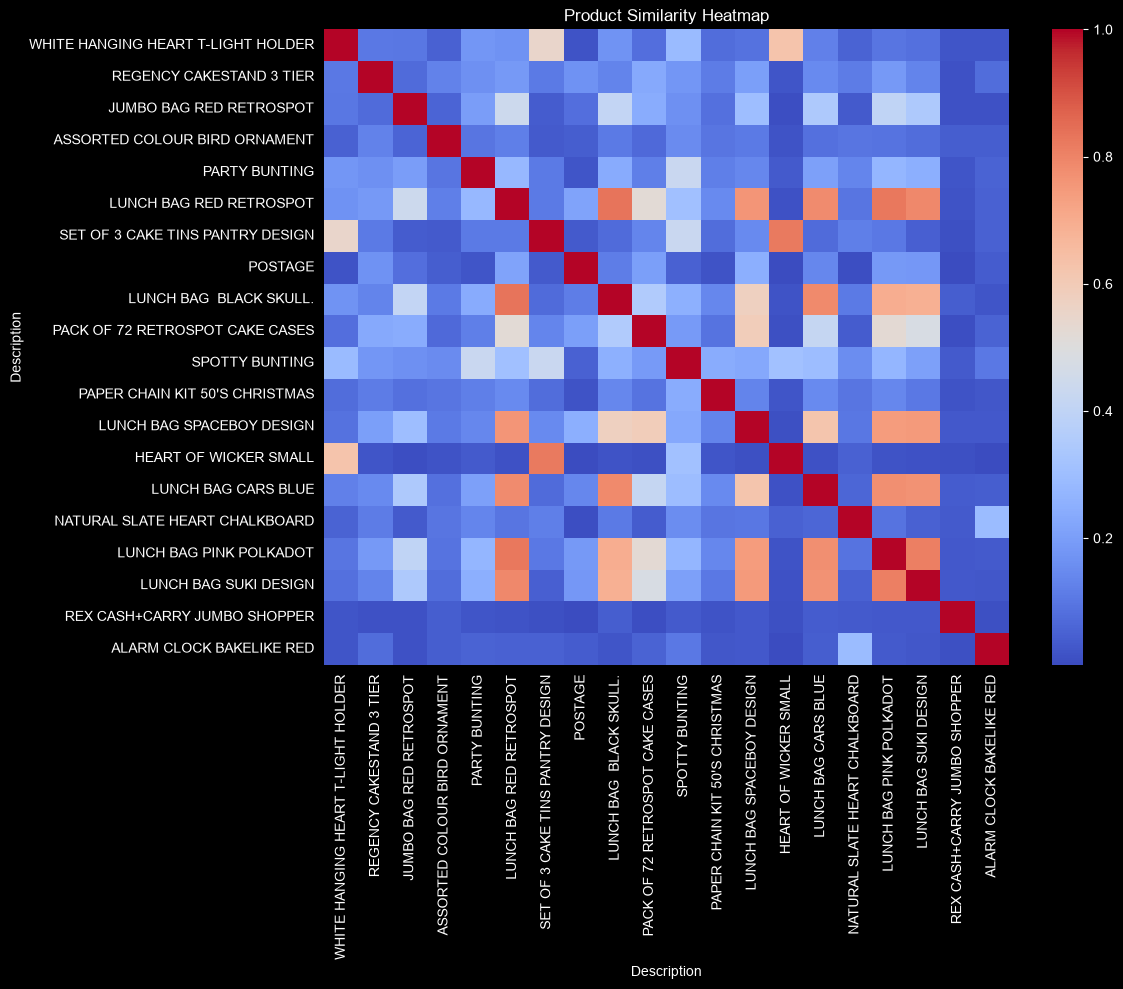

In [89]:
# Heatmap or Similarity Matrix

top_20_products = data["Description"].value_counts().head(20).index
small_similarity = product_similarity_df.loc[top_20_products, top_20_products]

plt.figure(figsize=(12, 10))
sns.heatmap(small_similarity, cmap="coolwarm")
plt.title("Product Similarity Heatmap")
plt.tight_layout()
plt.show()


In [90]:
# Creating prediction helper for customer segment

def predict_customer_segment(recency, frequency, monetary, scaler, model, cluster_name_map):
    input_df = pd.DataFrame([{
        "Recency": np.log1p(recency),
        "Frequency": np.log1p(frequency),
        "Monetary": np.log1p(monetary)
    }])

    scaled_input = scaler.transform(input_df)
    cluster = model.predict(scaled_input)[0]
    segment = cluster_name_map.get(cluster, f"Cluster {cluster}")
    return cluster, segment


In [125]:
import pickle
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans_final, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("cluster_name_map.pkl", "wb") as f:
    pickle.dump(cluster_name_map, f)

rfm.to_csv("rfm_segments.csv", index=False)

with open("product_similarity.pkl", "wb") as f:
    pickle.dump(product_similarity_df, f)

with open("customer_product_matrix.pkl","wb") as f:
    pickle.dump(customer_product_matrix, f)

print("All model artifacts saved successfully.")

All model artifacts saved successfully.
